In [2]:
import os
import sys
import pandas as pd
import numpy as np
import nibabel as nib
import h5py as h5

subject = 1

sys.path.append(os.path.abspath(".."))

from utils.config import Configuration, load_config

config = load_config("../config.yaml")

tsv_dir = os.path.join("..", config.nsd_data.nsddata_responses_tsv_dir)

In [3]:
t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"


import nibabel as nib



# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]

roi_sizes = []
roi_indices = []

for roi in range(1, 9):
    roi_indices_set = np.where(t_rois[t_indices] == roi)[0]
    roi_indices.append(roi_indices_set)
    roi_sizes.append(len(roi_indices_set))

In [4]:
subject_id = 1

tsv_path = os.path.join(
        tsv_dir,
        "ppdata",
        f"subj{subject_id:02d}",
        "behav",
        "responses.tsv",
    )

    # having all of the array loaded at once results in memory pressure
    # reduce to needed subset!

tsv_data = pd.read_csv(tsv_path, sep="\t")

In [5]:
from collections import Counter
import numpy as np
from collections import defaultdict



results = []

sample_dict = defaultdict(list)

for i in range(1, 40+1):
    result_dict_session = {}

    entries_session = tsv_data[tsv_data["SESSION"] == i]
    entry_ids = entries_session["73KID"].tolist()

    for entry_id in list(set(entry_ids)):
        entries_sample = entries_session[entries_session["73KID"] == entry_id]


        result_dict_session[entry_id] = {
            "count" : len(entries_sample) 
        }

        for row_i, row in entries_sample.iterrows():
            sample_dict[entry_id].append({
                "session" : int(row["SESSION"]),
                "index" : row_i,
                "session_index" : row_i - (int(row["SESSION"])-1)*750,
                "73KID" : entry_id
            }) 

            result_dict_session[entry_id]["session"] = int(row["SESSION"])
            result_dict_session[entry_id]["index"] = row_i
            result_dict_session[entry_id]["session_index"] = row_i - (int(row["SESSION"])-1)*750


    if i==1:
        print(result_dict_session)

    results.append(result_dict_session)


res_matrix = np.zeros((40, 40))
for i in range(40):
    entry_ids_i = list(results[i].keys())
    for j in range(40):
        if i==j:
            continue

        entry_ids_j = list(results[j].keys())

        overlap = list(set(entry_ids_i) & set(entry_ids_j))

        res_matrix[i,j] = len(overlap)
        res_matrix[j,i] = len(overlap)



{2050: {'count': 1, 'session': 1, 'index': 454, 'session_index': 454}, 38919: {'count': 1, 'session': 1, 'index': 215, 'session_index': 215}, 28681: {'count': 1, 'session': 1, 'index': 252, 'session_index': 252}, 38925: {'count': 3, 'session': 1, 'index': 493, 'session_index': 493}, 49171: {'count': 1, 'session': 1, 'index': 106, 'session_index': 106}, 28691: {'count': 3, 'session': 1, 'index': 517, 'session_index': 517}, 59411: {'count': 1, 'session': 1, 'index': 545, 'session_index': 545}, 47126: {'count': 2, 'session': 1, 'index': 664, 'session_index': 664}, 10263: {'count': 1, 'session': 1, 'index': 697, 'session_index': 697}, 38937: {'count': 2, 'session': 1, 'index': 719, 'session_index': 719}, 51228: {'count': 2, 'session': 1, 'index': 374, 'session_index': 374}, 18469: {'count': 1, 'session': 1, 'index': 51, 'session_index': 51}, 22565: {'count': 1, 'session': 1, 'index': 651, 'session_index': 651}, 28711: {'count': 2, 'session': 1, 'index': 658, 'session_index': 658}, 8236: {'

In [17]:
ids_to_loop = [
    18170, 34200, 16649, 28170, 58157, 57811, 46323, 2125, 18960, 67148, 
    1136, 17623, 41853, 12258, 65222, 45528, 3920, 15516, 39302, 46807, 
    25070, 60749, 59180, 60514, 63255, 67671, 14270, 15567, 17651, 19471, 
    40325, 41126, 58839, 14631, 21193
]


# ids_to_loop = [18170, 34200,  ]

ids_to_loop = [e + 1 for e in ids_to_loop]


correlations = []

plots = []
betas_results = []

t_test_rois_lh = "../data/t_test_roi/subj_01/lh.subj01.cleanedrois_3_0.mgz"
t_test_rois_rh = "../data/t_test_roi/subj_01/rh.subj01.cleanedrois_3_0.mgz"

# Load MGZ files
lh_img = nib.load(t_test_rois_lh)
rh_img = nib.load(t_test_rois_rh)
lh = lh_img.get_fdata()
rh = rh_img.get_fdata()
t_rois = np.concatenate((np.squeeze(lh), np.squeeze(rh)))

t_indices = np.where(t_rois != 0)[0]  # Indizes der nicht-Null ROIs
unique_rois = np.unique(t_rois[t_rois > 0])  # ROIs von 1 bis 8


betas_results = []
for id_loop in ids_to_loop:
    betas = []
    print(f"Looping {id_loop=}")

    session_numbers = [e["session"] for e in sample_dict[id_loop]]
    
    for session in list(set(session_numbers)):
        betas_dir = os.path.join(config.nsd_data.nsddata_betas_dir, "ppdata", f"subj{subject:02d}", "nativesurface", "betas_fithrf_GLMdenoise_RR")
        beta_lh = os.path.join(betas_dir, f"lh.betas_session{session:02d}.hdf5")
        beta_rh = os.path.join(betas_dir, f"rh.betas_session{session:02d}.hdf5")

        with h5.File(beta_lh, 'r') as f:
            betas_lh = f['betas'][:]

        with h5.File(beta_rh, 'r') as f:
            betas_rh = f['betas'][:]

        betas_concat = np.concatenate((betas_lh, betas_rh), axis=1)[:, t_indices]

        for sample in sample_dict[id_loop]:
            if sample["session"] == session:
                betas.append(betas_concat[sample["session_index"]])

    betas = np.vstack(betas)  # Alle gesammelten Betas in eine Matrix

    betas_results.append(betas)

Looping id_loop=18171
Looping id_loop=34201
Looping id_loop=16650
Looping id_loop=28171
Looping id_loop=58158
Looping id_loop=57812
Looping id_loop=46324
Looping id_loop=2126
Looping id_loop=18961
Looping id_loop=67149
Looping id_loop=1137
Looping id_loop=17624
Looping id_loop=41854
Looping id_loop=12259
Looping id_loop=65223
Looping id_loop=45529
Looping id_loop=3921
Looping id_loop=15517
Looping id_loop=39303
Looping id_loop=46808
Looping id_loop=25071
Looping id_loop=60750
Looping id_loop=59181
Looping id_loop=60515
Looping id_loop=63256
Looping id_loop=67672
Looping id_loop=14271
Looping id_loop=15568
Looping id_loop=17652
Looping id_loop=19472
Looping id_loop=40326
Looping id_loop=41127
Looping id_loop=58840
Looping id_loop=14632
Looping id_loop=21194


In [18]:
results_array = np.array(betas_results)



results_array_reshaped_standardized = results_array.reshape(results_array.shape[0] * 3, results_array.shape[-1])

In [19]:
for i in range(len(results_array_reshaped_standardized)):
    results_array_reshaped_standardized[i] = results_array_reshaped_standardized[i] / np.std(results_array_reshaped_standardized[i])

In [20]:
results_array.shape

(35, 3, 27321)

In [21]:
results_array_reshaped_standardized.shape

(105, 27321)

In [ ]:
import scipy.spatial.distance as dist
import matplotlib.pyplot as plt

import seaborn as sns

 


def pdist_to_matrix(data, metric='correlation'):
    """Compute pairwise distances and convert to a square matrix."""
    print(f"Using {metric=}")
    dist_array = dist.pdist(data, metric=metric)
    dist_matrix = dist.squareform(dist_array)
    return dist_matrix, dist_array

def normalize_matrix(matrix, dist_array):
    """Normalize the matrix values to the range [0, 1]."""
    min_val = np.min(dist_array)
    max_val = np.max(dist_array)

    #matrix =  (matrix - min_val) / (max_val - min_val)
    #dist_array =  (dist_array - min_val) / (max_val - min_val)


    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[0]):
            if i == j:
                pass
                #matrix[i][j] = 0

    return matrix, dist_array

import numpy as np

def mean_class_distance(matrix, labels):
    """
    Compute the mean and median intra-class and inter-class distances.
    
    Parameters:
    - matrix: A 2D numpy array (distance matrix), where matrix[i][j] is the distance between sample i and sample j.
    - labels: A 1D array of class labels for each sample.
    
    Returns:
    - mean_intra_class_distance: Mean distance among samples of the same class.
    - median_intra_class_distance: Median distance among samples of the same class.
    - mean_inter_class_distance: Mean distance among samples from different classes.
    - median_inter_class_distance: Median distance among samples from different classes.
    """
    unique_classes = np.unique(labels)
    all_intra_class_distances = []
    inter_class_distances = []

    # Intra-class distances (all pairwise distances within each class)
    for cls in unique_classes:
        indices = np.where(labels == cls)[0]
        if len(indices) > 1:
            for i in range(len(indices)):
                for j in range(i + 1, len(indices)):
                    all_intra_class_distances.append(matrix[indices[i]][indices[j]])

    # Inter-class distances (between all different class pairs)
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if labels[i] != labels[j]:
                inter_class_distances.append(matrix[i][j])

    mean_intra = np.mean(all_intra_class_distances) if all_intra_class_distances else 0
    median_intra = np.median(all_intra_class_distances) if all_intra_class_distances else 0
    mean_inter = np.mean(inter_class_distances) if inter_class_distances else 0
    median_inter = np.median(inter_class_distances) if inter_class_distances else 0

    return mean_intra, median_intra, mean_inter, median_inter




input_reshaped = results_array_reshaped_standardized

for roi in range(0, 8):
    results_array_reshaped_roi = input_reshaped[:, roi_indices[roi]]



    distance_matrix, dist_array = pdist_to_matrix(results_array_reshaped_roi, metric=emd)


    distance_matrix, dist_array = normalize_matrix(distance_matrix, dist_array)



    df_distance = pd.DataFrame(distance_matrix, columns=[f"P{i}" for i in range(len(results_array_reshaped_roi))], index=[f"P{i}" for i in range(len(results_array_reshaped_standardized))])


    labels = np.repeat(np.arange(results_array.shape[0]), 3)  # 5 classes, each with 3 observations
    # Compute mean distances
    mean_intra, median_intra, mean_inter, median_inter = mean_class_distance(distance_matrix, labels)
    ratio = mean_intra / mean_inter 
    print(f"ROI {roi=}")

    print(f"\nMean Intra-Class Distance: {mean_intra}")
    print(f"Mean Inter-Class Distance: {mean_inter}")

    print(f"Ratio (Intra-Class / Overall): {ratio}")

    print(f"\nMedian Intra-Class Distance: {median_intra}")
    print(f"Median Inter-Class Distance: {median_inter}")

# Plot using seaborn heatmap
#plt.figure(figsize=(12, 6))
#sns.heatmap(df_distance, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
#plt.title("Pairwise Distance Matrix (Euclidean)")
#plt.show()


Using metric=<function emd at 0x7f89cf18f2e0>
ROI roi=0

Mean Intra-Class Distance: 0.17511549923377503
Mean Inter-Class Distance: 0.23132972779025715
Ratio (Intra-Class / Overall): 0.7569952245504278

Median Intra-Class Distance: 0.15069469184182407
Median Inter-Class Distance: 0.1997387483671774
Using metric=<function emd at 0x7f89cf18f2e0>
ROI roi=1

Mean Intra-Class Distance: 0.1984997060552616
Mean Inter-Class Distance: 0.24355094465769847
Ratio (Intra-Class / Overall): 0.8150233468987169

Median Intra-Class Distance: 0.16493827160493826
Median Inter-Class Distance: 0.189135802469136
Using metric=<function emd at 0x7f89cf18f2e0>
ROI roi=2

Mean Intra-Class Distance: 0.12574675324675327
Mean Inter-Class Distance: 0.1621585603938545
Ratio (Intra-Class / Overall): 0.7754555352571989

Median Intra-Class Distance: 0.09346590909090904
Median Inter-Class Distance: 0.12215909090909091
Using metric=<function emd at 0x7f89cf18f2e0>
ROI roi=3

Mean Intra-Class Distance: 0.18701298701298702
M

Using metric='correlation'


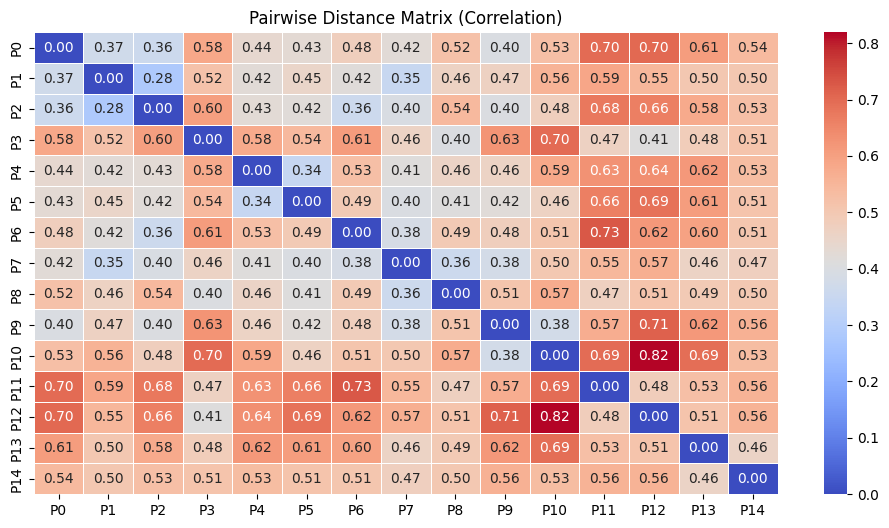

In [110]:
#results_array_reshaped = results_array.reshape(results_array.shape[0] * 3, results_array.shape[-1])[30:45, roi_indices[0]]

results_array_reshaped = results_array_reshaped_standardized[30:45, roi_indices[0]]


distance_matrix, dist_array = pdist_to_matrix(results_array_reshaped)


distance_matrix, dist_array = normalize_matrix(distance_matrix, dist_array)



df_distance = pd.DataFrame(distance_matrix, columns=[f"P{i}" for i in range(len(results_array_reshaped))], index=[f"P{i}" for i in range(len(results_array_reshaped))])


# Plot using seaborn heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_distance[:15], annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pairwise Distance Matrix (Correlation)")
plt.show()

In [94]:
a = [1,2,3,4]
b = [2, 4, 6, 8]
c = [1, 2, 3, 0]
d = [1,2,3,4]

dist_array = dist.pdist(np.array([a, b, c, d]), metric="correlation")

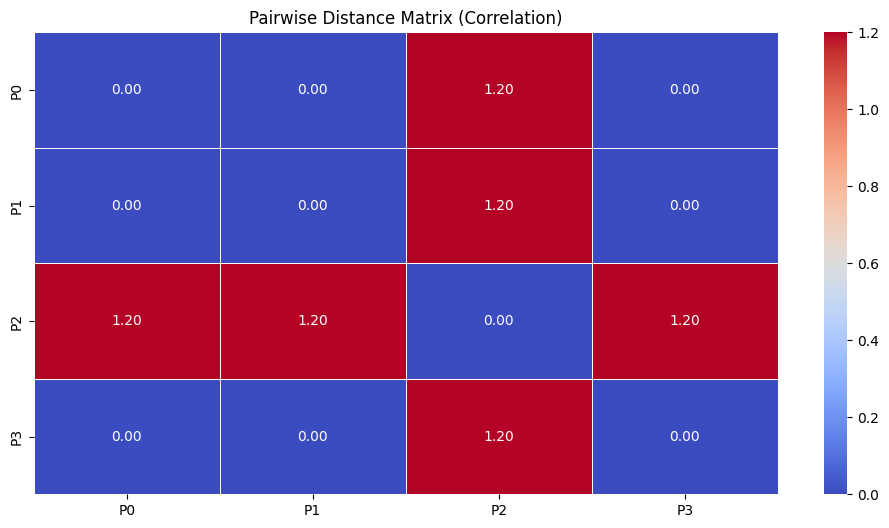

In [95]:
dist_matrix = dist.squareform(dist_array)

df_distance = pd.DataFrame(dist_matrix, columns=[f"P{i}" for i in range(len(dist_matrix))], index=[f"P{i}" for i in range(len(dist_matrix))])


# Plot using seaborn heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_distance, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pairwise Distance Matrix (Correlation)")
plt.show()